In [19]:
import numpy as np
import torch
import geoopt

def manifold_gaussian_pdf(x, mean, std, manifold):
    """
    Compute the probability density of a point x under a manifold Gaussian.
    """
    d = manifold.dist(torch.tensor(x), mean)  # Compute manifold distance
    return np.exp(-d**2 / (2 * std**2))  # Gaussian decay in manifold space

def sample_manifold_gaussian(n_samples, mean, variance, manifold, max_attempts=50000):
    """
    Sample from a manifold Gaussian using rejection sampling.
    
    Parameters:
    - n_samples (int): Number of points to sample.
    - mean (np.ndarray): Mean point in the manifold (shape: (2,))
    - std (float): Standard deviation in manifold space.
    - max_attempts (int): Maximum number of attempts before giving up.

    Returns:
    - np.ndarray: Sampled points in the manifold (shape: (n_samples, 2)).
    """
    samples = []
    attempts = 0
    
    while len(samples) < n_samples and attempts < max_attempts:
        # Propose a random point in the manifold
        radius = np.random.uniform(0,1/np.sqrt(np.abs(manifold.k)))
        theta = np.random.uniform(0, 2*np.pi)
        x = radius*np.array([np.cos(theta), np.sin(theta)])

        # Compute acceptance probability
        prob = manifold_gaussian_pdf(x, mean, variance,manifold)
        threshold = np.random.uniform(0, 1)  # Random uniform value

        if prob > threshold:  # Accept if it follows the Gaussian distribution
            samples.append(x)

        attempts += 1

    if len(samples) < n_samples:
        print("Warning: Could not generate enough points within max_attempts.")

    return torch.tensor(samples)



In [29]:

# Define the manifold manifold (Poincaré Ball)
manifold = geoopt.PoincareBall(c=1)  # Curvature c=1
radius = manifold.radius
# Step 1: Sample 4 centroids from a zero-mean manifold Gaussian (variance 1.5)
mean_zero = torch.zeros(2)  # Center at origin
centroid_var = 1 * radius.numpy()  
n_centroids = 4 
centroids = sample_manifold_gaussian(n_samples=n_centroids, mean=mean_zero, variance=centroid_var, manifold=manifold)

# Step 2: Sample 100 points around each centroid (unit variance)
dataset = []
tan_dataset = []
labels = []
c_labels =[]
num_sampels = 100

# Variable variance for each cluster 
var_percents = np.random.uniform(0.15, 0.5, n_centroids) 

# Define the variance according to the radius of the space for realistic clusters
vars = var_percents * radius.numpy()
for i, centroid in enumerate(centroids):
    points = sample_manifold_gaussian(n_samples=num_sampels, mean=centroid, variance=vars[i], manifold=manifold)
    dataset.append(points)
    tan_dataset.append(manifold.logmap(points, centroid)+manifold.logmap0(centroid))
    
    labels.extend([i] * len(points))  # Assign class labels
    c_labels.append(i)

# Convert to NumPy
dataset = torch.cat(dataset).numpy()
tan_dataset = torch.cat(tan_dataset).numpy()
labels = np.array(labels)

tan_centroids = manifold.logmap0(centroids)


/tmp/ipykernel_1673541/269608516.py:3: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  color_map = plt.cm.get_cmap('viridis', len(centroids))


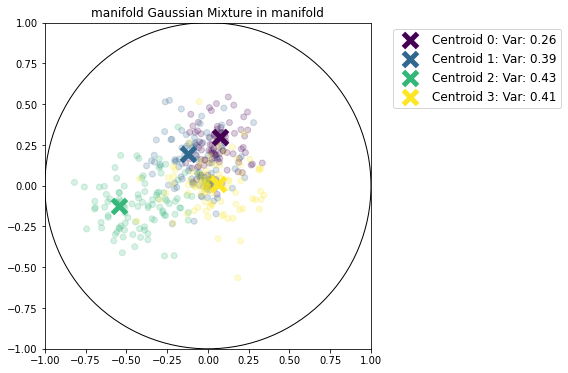

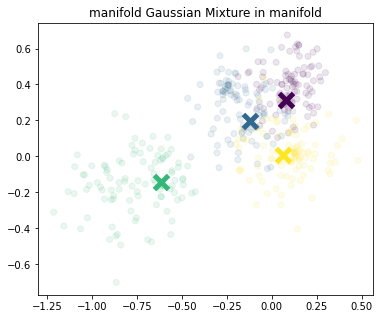

In [31]:
import matplotlib.pyplot as plt

color_map = plt.cm.get_cmap('viridis', len(centroids))
fig, ax = plt.subplots(figsize=(6,6))
ax.add_patch(plt.Circle((0, 0), radius, color='black', fill=False))  # manifold boundary
scatter = plt.scatter(dataset[:, 0], dataset[:, 1], c=labels, cmap='viridis', alpha=0.2)
for i, centroid in enumerate(centroids):
    plt.scatter(centroid[0], centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")
    
plt.xlim(-radius, radius)
plt.ylim(-radius, radius)
plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left',fontsize = 12)
plt.show()


fig, ax = plt.subplots(figsize=(6,6))
scatter = plt.scatter(tan_dataset[:, 0], tan_dataset[:, 1], c=labels, cmap='viridis', alpha=0.1)
# plt.scatter(tan_centroids[:, 0], tan_centroids[:, 1], c=c_labels, marker='x', s=200, linewidths= 5, label="Centroids")
for i, tan_centroid in enumerate(tan_centroids):
    plt.scatter(tan_centroid[0], tan_centroid[1], color=color_map(c_labels[i]), marker='x', s=200, linewidths=5, label=f"Centroid {i}: Var: {vars[i]:.2f}")

plt.gca().set_aspect('equal', adjustable='box')
plt.title("manifold Gaussian Mixture in manifold")
plt.show()